# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


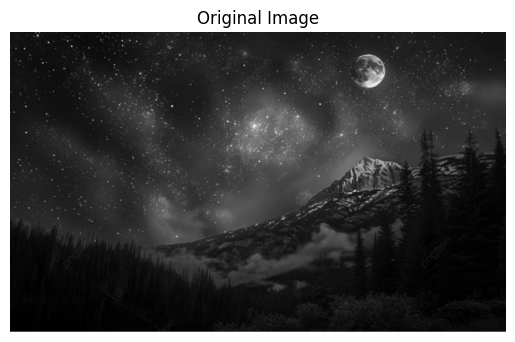

In [18]:
# ── Load image ────────────────────────────────────
img = Image.open('stars.png').convert('L')


plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [19]:
# Get the size of the image
width, height = img.size
print(f"Width: {width}, Height: {height}")
# scaling factors
scale_factor = 2

Width: 1694, Height: 1024


Scaled size: (3388, 2048)


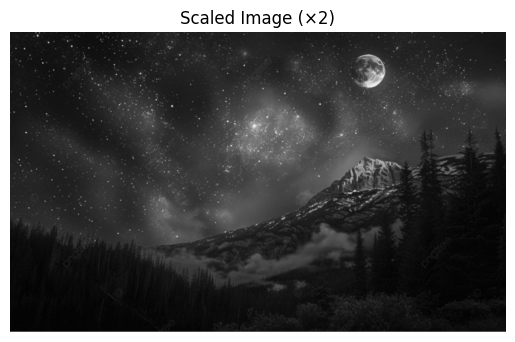

In [23]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_img = img.resize((width * scale_factor, height * scale_factor), resample=Image.Resampling.LANCZOS)

print(f"Scaled size: {scaled_img.size}")

plt.imshow(scaled_img, cmap='gray')
plt.title('Scaled Image (×2)')
plt.axis('off')
plt.show()

In [28]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (1694, 1024)
Scaled size: (3388, 2048)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [27]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)
rotated_img.save("task1_2_rotated.jpg")
print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

Original size: (1694, 1024)
Rotated size: (1734, 1980)


### 3. Shear

In [29]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print(f"Width: {width}, Height: {height}")

Width: 1694, Height: 1024


In [30]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shear_matrix = (1, shear_factor, 0, 0, 1, 0)
new_width = int(width + abs(shear_factor) * height)
new_height = height

In [31]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC,
)


Sheared image size: (2206, 1024)


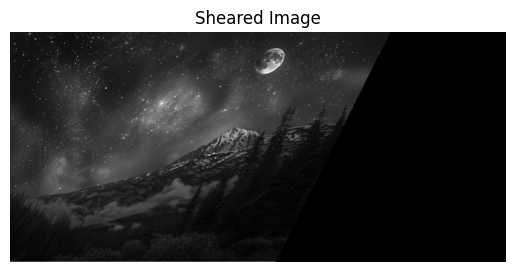

In [32]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print(f"Sheared image size: {sheared_img.size}")

plt.imshow(sheared_img, cmap='gray')
plt.title('Sheared Image')
plt.axis('off')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

(np.float64(-0.5), np.float64(1693.5), np.float64(1023.5), np.float64(-0.5))

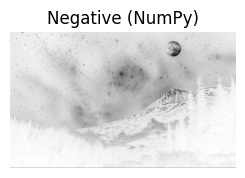

In [35]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_arr = np.array(img, dtype=np.uint8)
negative_arr = 255 - img_arr
negative_img_np = Image.fromarray(negative_arr)
negative_img_np.save("task2_1_negative_np.jpg")

plt.subplot(1, 2, 1)
plt.imshow(negative_img_np, cmap='gray')
plt.title('Negative (NumPy)')
plt.axis('off')



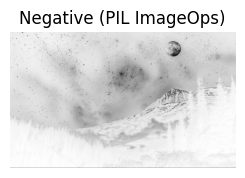

In [36]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)
negative_img_pil.save("task2_1_negative_pil.jpg")

plt.subplot(1, 2, 2)
plt.imshow(negative_img_pil, cmap='gray')
plt.title('Negative (PIL ImageOps)')
plt.axis('off')
plt.show()

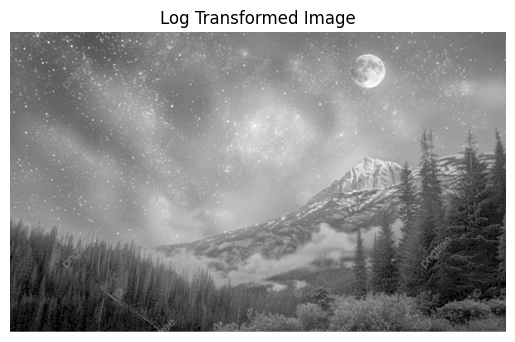

In [38]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

r = np.array(img, dtype=np.float32)
c = 255.0 / np.log(1.0 + 255.0)

# Apply the log transformation to each pixel
s = c * np.log(1.0 + r)
log_transformed_arr = Image.fromarray(np.uint8(np.clip(s, 0, 255)))

# Save the image ("task2_2_log.jpg"
log_transformed_arr.save("task2_2_log.jpg")

plt.imshow(log_transformed_arr, cmap='gray')
plt.title('Log Transformed Image')
plt.axis('off')
plt.show()

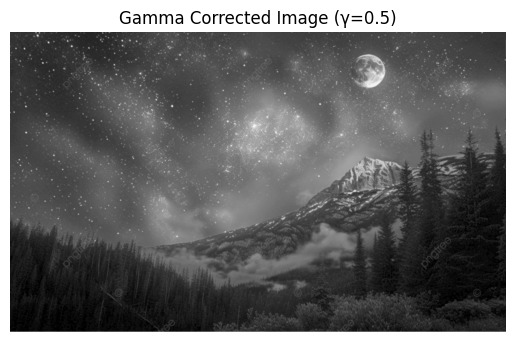

In [46]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
r_norm = np.array(img, dtype=np.float32) / 255.0
gamma_corrected = np.power(r_norm, gamma) * 255.0
gamma_img = Image.fromarray(np.uint8(np.clip(gamma_corrected, 0, 255)))

gamma_img.save("task2_3_gamma.jpg")

plt.imshow(gamma_img, cmap='gray')
plt.title(f'Gamma Corrected Image (γ={gamma})')
plt.axis('off')
plt.show()